In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [15]:
df = pd.read_csv(r"D:\AI\Artificial-Intelligence-Machine-Learning-and-Deep-Learning-Corvit-Peshawar-2026\Artificial-Inteligence-Machine-Learning-and-Deep-Learning-NAVTTC-Course-2026\week-06-regression-and-classification-ML\datasets\students_logistic.csv")

In [16]:
df.head()

,Unnamed: 0,study_hours,pass
0,0,1.0,0
1,1,1.5,0
2,2,2.0,0
3,3,2.5,0
4,4,3.0,0


In [17]:
x = df['study_hours'].values
y = df['pass'].values

print(type(x))
print(type(y))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [ ]:
x = x.reshape(-1, 1)

In [21]:
x.shape

(19, 1)

In [22]:
y.shape

(19,)

In [23]:
x.min()

1.0

In [24]:
x.max()

10.0

In [25]:
y.unique()

AttributeError: 'numpy.ndarray' object has no attribute 'unique'

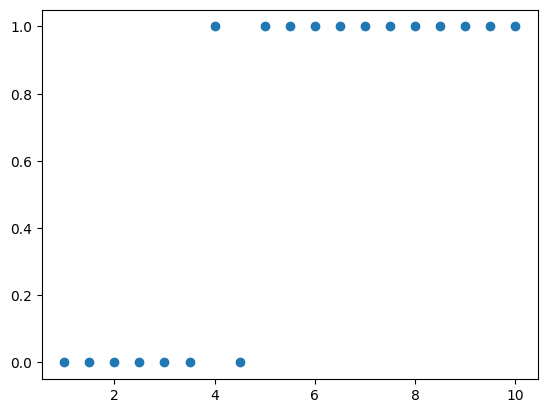

In [26]:
plt.scatter(x, y)


In [27]:
model = LinearRegression().fit(x, y)

In [28]:
pred = model.predict(x)

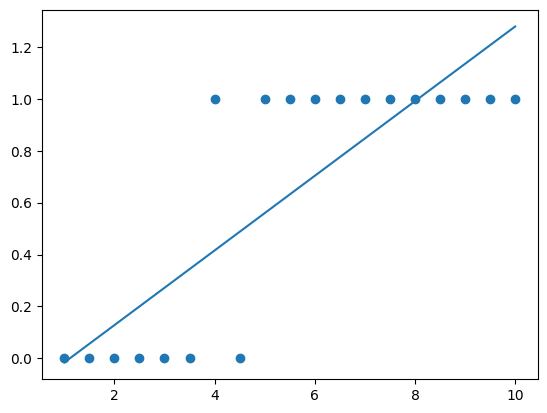

In [30]:
plt.scatter(x, y)
plt.plot(x, pred)

In [31]:
def segmoid(z):
    return (1/(1 + np.exp(-(z))))

In [32]:
seg_out = segmoid(pred)

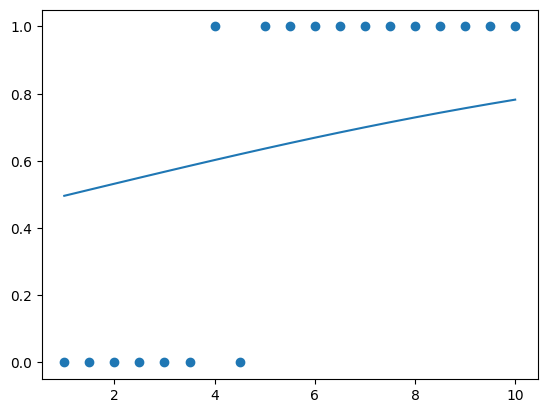

In [33]:
plt.scatter(x, y)
plt.plot(x, seg_out)

In [34]:
pred

array([-0.01578947,  0.05614035,  0.12807018,  0.2       ,  0.27192982,
        0.34385965,  0.41578947,  0.4877193 ,  0.55964912,  0.63157895,
        0.70350877,  0.7754386 ,  0.84736842,  0.91929825,  0.99122807,
        1.06315789,  1.13508772,  1.20701754,  1.27894737])

In [38]:
df[['study_hours']]

,study_hours
0,1.0
1,1.5
2,2.0
3,2.5
4,3.0
5,3.5
6,4.0
7,4.5
8,5.0
9,5.5


In [39]:
x

array([[ 1. ],
       [ 1.5],
       [ 2. ],
       [ 2.5],
       [ 3. ],
       [ 3.5],
       [ 4. ],
       [ 4.5],
       [ 5. ],
       [ 5.5],
       [ 6. ],
       [ 6.5],
       [ 7. ],
       [ 7.5],
       [ 8. ],
       [ 8.5],
       [ 9. ],
       [ 9.5],
       [10. ]])

In [40]:
df

,Unnamed: 0,study_hours,pass
0,0,1.0,0
1,1,1.5,0
2,2,2.0,0
3,3,2.5,0
4,4,3.0,0
5,5,3.5,0
6,6,4.0,1
7,7,4.5,0
8,8,5.0,1
9,9,5.5,1


In [41]:
x.shape

(19, 1)

In [42]:
y.shape

(19,)

In [98]:
x = x.flatten()

print(x)
print(y)

[ 1.   1.5  2.   2.5  3.   3.5  4.   4.5  5.   5.5  6.   6.5  7.   7.5
  8.   8.5  9.   9.5 10. ]
[0 0 0 0 0 0 1 0 1 1 1 1 1 1 1 1 1 1 1]


In [122]:
def predict(x, w, b):
    z = w * x + b
    sig = 1/(1 + np.exp(-z))
    return sig

In [99]:
def cost(x, y, w, b):
    y_hat = predict(x, w, b)
    e = 1e-9
    loss = -np.mean(y*np.log(y_hat+e) + (1-y)*np.log(1 - y_hat + e))
    return loss

In [100]:
def gradient(x, y, w, b):
    y_hat = predict(x, w, b)
    error = (y_hat - y)
    gw = np.mean(error*x)
    gb = np.mean(error)
    return gw, gb

In [103]:
w, b = 0.0, 0.0
alpha = 0.01
history = []

for i in range(1, 5001):
    gw, gb = gradient(x, y, w, b)
    w = w - alpha * gw
    b = b - alpha * gb
    c = cost(x, y, w, b)
    history.append(c)

    print(f"Epoch : {i} ------  cost : {c}")

Epoch : 1 ------  cost : 0.6620440684324648
Epoch : 2 ------  cost : 0.6365969862387345
Epoch : 3 ------  cost : 0.6157224420134256
Epoch : 4 ------  cost : 0.5985304735829601
Epoch : 5 ------  cost : 0.5843028885364272
Epoch : 6 ------  cost : 0.5724659510373892
Epoch : 7 ------  cost : 0.562563517905941
Epoch : 8 ------  cost : 0.5542333329575339
Epoch : 9 ------  cost : 0.547187292269481
Epoch : 10 ------  cost : 0.5411955554051927
Epoch : 11 ------  cost : 0.5360739977775979
Epoch : 12 ------  cost : 0.5316744064918002
Epoch : 13 ------  cost : 0.5278768586790824
Epoch : 14 ------  cost : 0.5245838049527293
Epoch : 15 ------  cost : 0.5217154719196105
Epoch : 16 ------  cost : 0.519206280304122
Epoch : 17 ------  cost : 0.5170020440234504
Epoch : 18 ------  cost : 0.5150577703442633
Epoch : 19 ------  cost : 0.5133359238224712
Epoch : 20 ------  cost : 0.5118050493377402
Epoch : 21 ------  cost : 0.5104386743215167
Epoch : 22 ------  cost : 0.5092144290508894
Epoch : 23 ------  cos

In [104]:
pred = predict(x, w, b)

In [105]:
pred

array([0.07350671, 0.11035496, 0.16243639, 0.23266906, 0.3216081 ,
       0.42568418, 0.53679037, 0.64435977, 0.7390906 , 0.81580148,
       0.87380916, 0.91544254, 0.94421695, 0.96358906, 0.97640184,
       0.98477711, 0.9902097 , 0.99371594, 0.99597158])

In [106]:
y

array([0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
      dtype=int64)

In [108]:
pred_c = np.where(pred < 0.5, 0, 1)

In [109]:
pred_c

array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [115]:
(pred_c == y).sum()/len(y) * 100

94.73684210526315

In [123]:
y_hat = predict(x, w, b)

In [124]:
y_hat

array([0.07350671, 0.11035496, 0.16243639, 0.23266906, 0.3216081 ,
       0.42568418, 0.53679037, 0.64435977, 0.7390906 , 0.81580148,
       0.87380916, 0.91544254, 0.94421695, 0.96358906, 0.97640184,
       0.98477711, 0.9902097 , 0.99371594, 0.99597158])

In [125]:
error = y_hat - y

In [126]:
error

array([ 0.07350671,  0.11035496,  0.16243639,  0.23266906,  0.3216081 ,
        0.42568418, -0.46320963,  0.64435977, -0.2609094 , -0.18419852,
       -0.12619084, -0.08455746, -0.05578305, -0.03641094, -0.02359816,
       -0.01522289, -0.0097903 , -0.00628406, -0.00402842])

In [133]:
pred

array([0.07350671, 0.11035496, 0.16243639, 0.23266906, 0.3216081 ,
       0.42568418, 0.53679037, 0.64435977, 0.7390906 , 0.81580148,
       0.87380916, 0.91544254, 0.94421695, 0.96358906, 0.97640184,
       0.98477711, 0.9902097 , 0.99371594, 0.99597158])

In [136]:
z

array([-2.53403011, -2.08712044, -1.64021076, -1.19330109, -0.74639142,
       -0.29948174,  0.14742793,  0.5943376 ,  1.04124728,  1.48815695,
        1.93506662,  2.3819763 ,  2.82888597,  3.27579564,  3.72270532,
        4.16961499,  4.61652466,  5.06343434,  5.51034401])

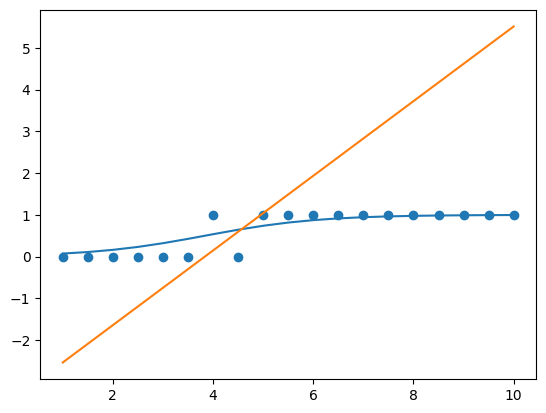

In [135]:

plt.scatter(x, y)
plt.plot(x, pred)
z = w * x + b
plt.plot(x, z)

In [137]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

In [155]:
x_train, x_test, y_train, y_test = train_test_split(df[["study_hours"]], df['pass'], test_size=0.5, random_state=42)

In [158]:
print("x train shape : ",x_train.shape)
print("x test shape : ",x_test.shape)
print("y train shape : ",y_train.shape)
print("y test shape : ",y_test.shape)

x train shape :  (9, 1)
x test shape :  (10, 1)
y train shape :  (9,)
y test shape :  (10,)


In [159]:
model = LogisticRegression()

In [160]:
model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [161]:
pred = model.predict(x_train)

In [162]:
accuracy_score(y_train, pred)

0.7777777777777778

In [163]:
pred_test = model.predict(x_test)

In [164]:
accuracy_score(y_test, pred_test)

1.0

In [165]:
y_test

0     0
5     0
11    1
1     0
8     1
16    1
3     0
13    1
15    1
17    1
Name: pass, dtype: int64

In [166]:
pred_test

array([0, 0, 1, 0, 1, 1, 0, 1, 1, 1], dtype=int64)

In [167]:
confusion_matrix(pred_test, y_test)

array([[4, 0],
       [0, 6]], dtype=int64)